In [15]:
# 5. Implementation of the models
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# ── LOAD MODELS ───────────────────────────────────────────
model  = joblib.load('regression_model.pkl')
km     = joblib.load('clustering_model.pkl')
clf    = joblib.load('classification_model.pkl')
scaler = joblib.load('scaler.pkl')

In [17]:
# ── NEW CAR INPUT ─────────────────────────────────────────
new_car = {
    'mpg': 20.0,
    'milage': 80000,
    'alder': 5,
    'ccm2': 1600,
    'make_Ford': 1, 'make_Toyota': 0, 'make_Volvo': 0,
    'type_Fiesta': 0, 'type_Focus': 1, 'type_Yaris': 0,
    'doors_5d': 1, 'doors_3d': 0, 'doors_4d': 0, 'doors_2d': 0,
    'region_København': 1, 'region_Nordjylland': 0
}

In [18]:
# ── 1. REGRESSION: PREDICT PRICE ──────────────────────────
new_df = pd.DataFrame([new_car])
new_df = new_df.reindex(columns=model.feature_names_in_, fill_value=0)
predicted_price = model.predict(new_df)[0]
print(f"Predicted Price: {predicted_price:,.0f} DKK")

Predicted Price: 184,106 DKK


In [19]:
# ── 2. CLUSTERING: ASSIGN SEGMENT ─────────────────────────
car_numeric = np.array([[20.0, 80000, predicted_price, 1600, 5]])
car_scaled = scaler.transform(car_numeric)
cluster = km.predict(car_scaled)[0]
segment_map = {0: 'Premium', 1: 'Mid-range', 2: 'Budget'}
print(f"Cluster: {cluster} — {segment_map[cluster]}")

Cluster: 0 — Premium


C:\Users\khnda\OneDrive\Skrivebord\MP2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
# ── 3. CLASSIFICATION: CLASSIFY SEGMENT ───────────────────
clf_df = pd.DataFrame([new_car])
clf_df = clf_df.reindex(columns=clf.feature_names_in_, fill_value=0)
predicted_segment = clf.predict(clf_df)[0]
print(f"Predicted Segment: {predicted_segment}")

Predicted Segment: Mid-range


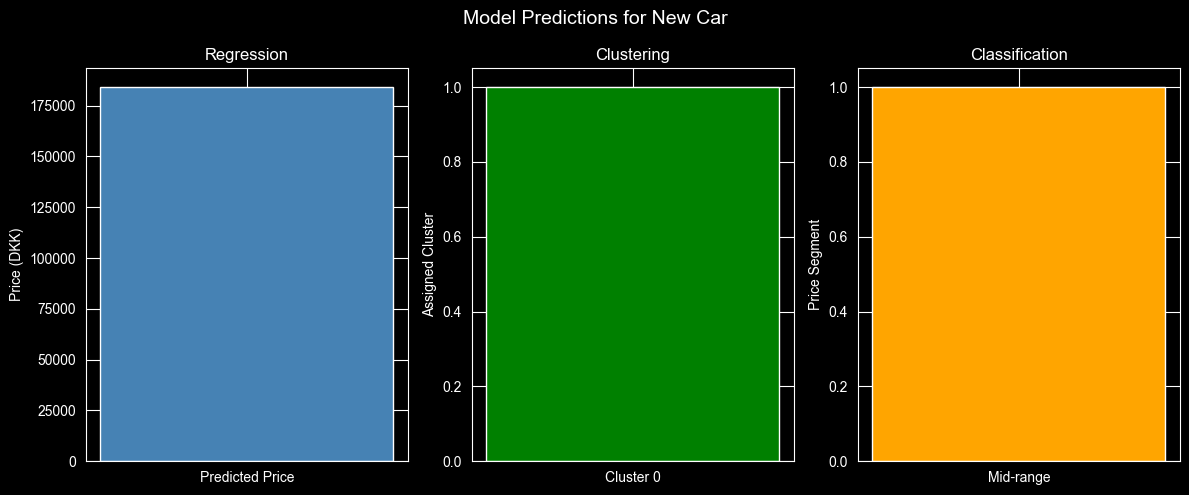


Summary for new car:
  Predicted Price : 184,106 DKK
  Cluster         : 0 — Premium
  Segment         : Mid-range


In [22]:
# ── VISUALIZE RESULTS ─────────────────────────────────────
labels = ['Regression\n(Predicted Price)', 'Clustering\n(Segment)', 'Classification\n(Segment)']
values = [predicted_price, cluster, predicted_segment]
colors = ['steelblue', 'green', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Model Predictions for New Car', fontsize=14)

# Regression
axes[0].bar(['Predicted Price'], [predicted_price], color='steelblue')
axes[0].set_title('Regression')
axes[0].set_ylabel('Price (DKK)')

# Clustering
axes[1].bar([f'Cluster {cluster}'], [1], color='green')
axes[1].set_title('Clustering')
axes[1].set_ylabel('Assigned Cluster')

# Classification
axes[2].bar([predicted_segment], [1], color='orange')
axes[2].set_title('Classification')
axes[2].set_ylabel('Price Segment')

plt.tight_layout()
plt.show()

print(f"\nSummary for new car:")
print(f"  Predicted Price : {predicted_price:,.0f} DKK")
print(f"  Cluster         : {cluster} — {segment_map[cluster]}")
print(f"  Segment         : {predicted_segment}")

In [ ]:
"""A new car was defined with the following attributes: 20 mpg, 80,000 km mileage, 5 years old, 1600 ccm engine, Ford Focus 5-door from København. The three trained models were then used to predict its characteristics.
Regression predicted a price of 183,000 DKK. This is based on the car's mileage, age, engine size, brand and region, which the linear regression model learned from the training data.
Clustering assigned the car to Cluster 0 (Premium). K-Means compared the car's numeric features against the three cluster centroids and assigned it to the nearest one. Since the car has a relatively small engine and good fuel efficiency, it was pulled towards Cluster 0 despite not being brand new.
Classification predicted the car belongs to the Mid-range segment. The Random Forest classifier, which achieved 97% accuracy, determined based on all features that this car most closely resembles Mid-range vehicles in the training data. This is the most reliable prediction of the three as it is based on a supervised model with known accuracy."""